In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from xgboost import XGBRegressor

In [3]:
orders = pd.read_excel("transformed_data/orders_transformed.xlsx")
payments = pd.read_excel("transformed_data/payments_transformed.xlsx")

In [4]:
### convert date column

In [5]:
orders["order_purchase_timestamp"] = pd.to_datetime(
    orders["order_purchase_timestamp"]
)

In [6]:
### merge tables

In [7]:
sales_data = orders.merge(
    payments,
    on="order_id"
)

In [8]:
### create year and month features

In [9]:
sales_data["Year"] = sales_data[
    "order_purchase_timestamp"
].dt.year

sales_data["Month"] = sales_data[
    "order_purchase_timestamp"
].dt.month

In [10]:
### create date column for visualization

In [11]:
monthly_sales = sales_data.groupby(
    ["Year", "Month"]
)["payment_value"].sum().reset_index()

In [12]:
### create date column for visualization

In [13]:
monthly_sales["Date"] = pd.to_datetime(
    monthly_sales["Year"].astype(str)
    + "-"
    + monthly_sales["Month"].astype(str)
)

In [14]:
### create time index

In [15]:
monthly_sales["Time_Index"] = range(
    1,
    len(monthly_sales) + 1
)

In [16]:
### define features and target

In [17]:
X = monthly_sales[[
    "Time_Index",
    "Year",
    "Month"
]]

y = monthly_sales["payment_value"]

In [18]:
### train Xgboost model

In [19]:
model = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=5,
    random_state=42
)

model.fit(X, y)

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_met

In [20]:
### error evaluation

In [21]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

train_pred = model.predict(X)

mae = mean_absolute_error(y, train_pred)
rmse = np.sqrt(mean_squared_error(y, train_pred))

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 15669.524000000003
RMSE: 19112.914411203546


In [22]:
### create next 12 months

In [23]:
future_dates = pd.date_range(
    start=monthly_sales["Date"].max(),
    periods=13,
    freq="ME"
)[1:]

In [24]:
### create future dataframe

In [25]:
future_df = pd.DataFrame()

future_df["Date"] = future_dates

future_df["Year"] = future_df["Date"].dt.year

future_df["Month"] = future_df["Date"].dt.month

In [26]:
future_df.head()

,Date,Year,Month
0,2026-06-30,2026,6
1,2026-07-31,2026,7
2,2026-08-31,2026,8
3,2026-09-30,2026,9
4,2026-10-31,2026,10


In [27]:
### create future time index

In [28]:
future_df["Time_Index"] = range(
    monthly_sales["Time_Index"].max() + 1,
    monthly_sales["Time_Index"].max() + 13
)

In [29]:
### forecast future revenue (1 year)

In [30]:
future_df["Forecasted_Revenue"] = model.predict(
    future_df[[
        "Time_Index",
        "Year",
        "Month"
    ]]
)

In [31]:
### view future revenue

In [32]:
future_df[[
    "Date",
    "Forecasted_Revenue"
]]

,Date,Forecasted_Revenue
0,2026-06-30,4655089.5
1,2026-07-31,4653040.5
2,2026-08-31,4653040.5
3,2026-09-30,4612660.0
4,2026-10-31,4688805.0
5,2026-11-30,4623464.5
6,2026-12-31,4683439.5
7,2027-01-31,4658399.5
8,2027-02-28,4637117.0
9,2027-03-31,4663715.0


In [33]:
### forecast fusture revenue on graph (1 year)

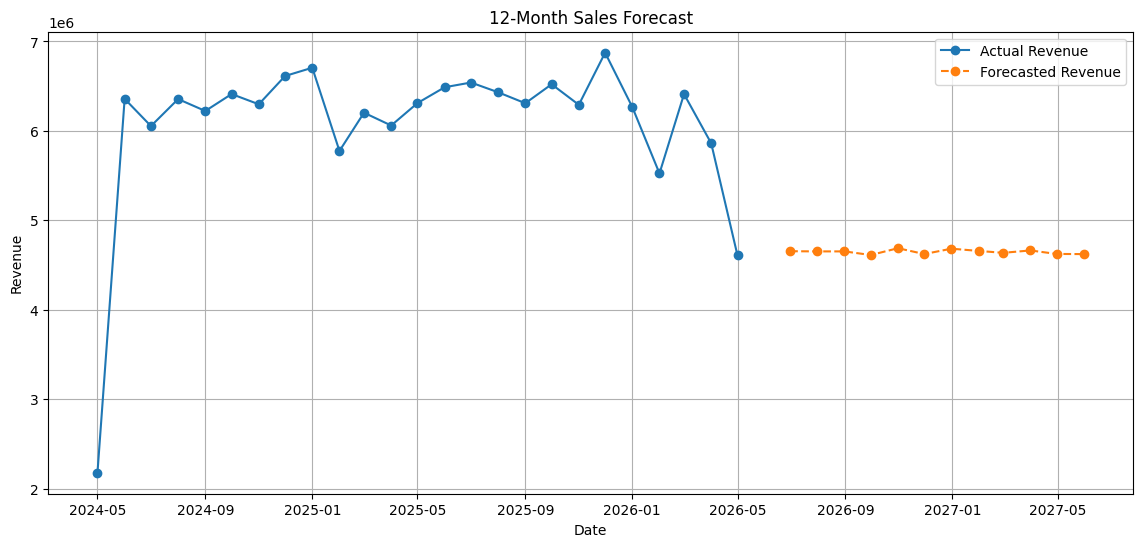

In [34]:
plt.figure(figsize=(14,6))

plt.plot(
    monthly_sales["Date"],
    monthly_sales["payment_value"],
    marker="o",
    label="Actual Revenue"
)

plt.plot(
    future_df["Date"],
    future_df["Forecasted_Revenue"],
    marker="o",
    linestyle="--",
    label="Forecasted Revenue"
)

plt.xlabel("Date")

plt.ylabel("Revenue")

plt.title("12-Month Sales Forecast")

plt.legend()

plt.grid(True)

plt.show()

In [35]:
### prediction function

In [36]:
def predict_sales(year, month):

    latest_revenue = monthly_sales[
        "payment_value"
    ].iloc[-1]

    next_index = future_df[
        (future_df["Year"] == year)
        &
        (future_df["Month"] == month)
    ]["Time_Index"]

    if next_index.empty:
        print("Forecast not available")
        return

    prediction = model.predict(
        pd.DataFrame({
            "Time_Index": [next_index.values[0]],
            "Year": [year],
            "Month": [month]
        })
    )[0]

    difference = prediction - latest_revenue

    print(f"Forecast for {month}/{year}")

    print("-" * 40)

    print(
        f"Current Revenue     : ₹{latest_revenue:,.2f}"
    )

    print(
        f"Forecasted Revenue  : ₹{prediction:,.2f}"
    )

    print(
        f"Difference          : ₹{difference:,.2f}"
    )

In [37]:
### predict future sales

In [38]:
predict_sales(2026, 7)

Forecast for 7/2026
----------------------------------------
Current Revenue     : ₹4,607,488.21
Forecasted Revenue  : ₹4,653,040.50
Difference          : ₹45,552.29


In [41]:
predict_sales(2027, 2)

Forecast for 2/2027
----------------------------------------
Current Revenue     : ₹4,607,488.21
Forecasted Revenue  : ₹4,637,117.00
Difference          : ₹29,628.79


### save forecast table

In [73]:
forecast_table = future_df[[
    "Date",
    "Year",
    "Month",
    "Forecasted_Revenue"
]]
forecast_table.to_csv("revenue_forecast_next_12_months.csv", index=False)

Forecast table saved successfully!
